# Análisis Estocástico — Resúmenes y Ejercicios
**Ximena Quintanar**  
16 de junio de 2026

Ejercicios computacionales basados en: *Cambio de medida en probabilidad y análisis estocástico* (César Galindo).  
Temas: Radon-Nikodym, algoritmos genéticos, martingalas, MCMC, Kolmogorov-Smirnov, Markowitz, Adam.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, norm

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "monospace",
})


## 1. Cambio de medida — Radon-Nikodym

Si $Z \geq 0$ con $E_P[Z] = 1$, definimos $Q(A) = \int_A Z\, dP$.  
La identidad fundamental es $E_Q[X] = E_P[XZ]$.

Aquí: $P = \text{Uniforme}[0,1]$, $Z(x) = 2x$, verificamos que $E_Q[X^2] = 1/2$.


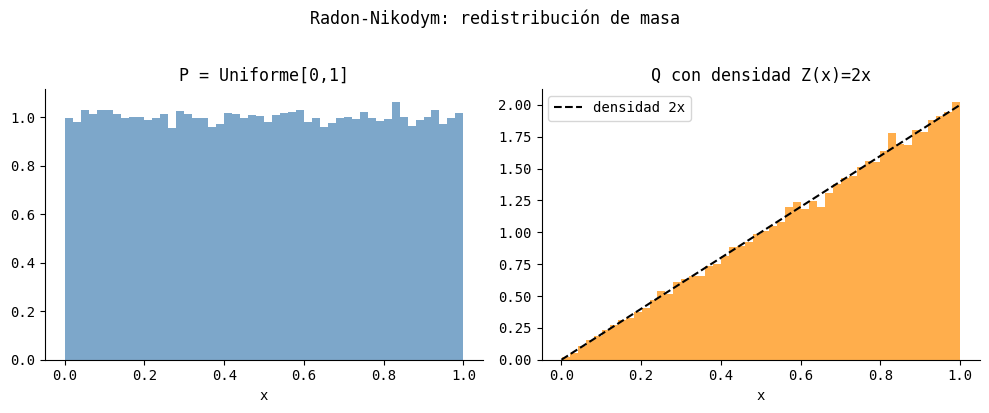

E_P[X²] = 0.3330  (esperado: 0.3333)
E_Q[X²] = 0.4997  (esperado: 0.5000)


In [2]:
np.random.seed(0)
n = 100_000
x = np.random.uniform(0, 1, n)
Z = 2 * x

ep_x2 = np.mean(x**2)
eq_x2 = np.mean(x**2 * Z)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(x, bins=50, density=True, color="steelblue", alpha=0.7)
axes[0].set_title("P = Uniforme[0,1]")
axes[0].set_xlabel("x")

x_grid = np.linspace(0, 1, 200)
axes[1].hist(np.random.choice(x, size=n, p=Z/Z.sum()), bins=50,
             density=True, color="darkorange", alpha=0.7)
axes[1].plot(x_grid, 2*x_grid, "k--", lw=1.5, label="densidad 2x")
axes[1].set_title("Q con densidad Z(x)=2x")
axes[1].set_xlabel("x")
axes[1].legend()

plt.suptitle("Radon-Nikodym: redistribución de masa", y=1.02)
plt.tight_layout()
plt.show()

print(f"E_P[X²] = {ep_x2:.4f}  (esperado: 0.3333)")
print(f"E_Q[X²] = {eq_x2:.4f}  (esperado: 0.5000)")


## 2. Algoritmo genético — operador replicador-mutador

Espacio $\Theta = \{0,1,2\}$, fitness $F(i) = i$, potencial $G = e^F$.  
La dinámica es: $\eta_{n+1} = \Psi_G(\eta_n) \cdot M$, donde $M$ es el núcleo de mutación.  
Por Perron-Frobenius, la población converge a una distribución límite $\pi^*$.


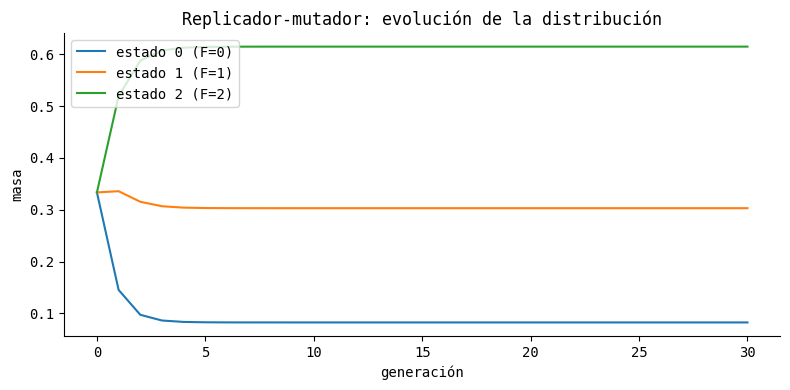

Distribución límite π* ≈ [0.0825 0.3029 0.6146]


In [3]:
M = np.array([
    [0.70, 0.25, 0.05],
    [0.20, 0.60, 0.20],
    [0.05, 0.25, 0.70],
])

eta = np.array([1/3, 1/3, 1/3])
estados = np.array([0., 1., 2.])
historia = [eta.copy()]

for _ in range(30):
    G = np.exp(estados)
    eta_sel = G * eta / (G @ eta)
    eta = eta_sel @ M
    historia.append(eta.copy())

historia = np.array(historia)

fig, ax = plt.subplots(figsize=(8, 4))
for i, label in enumerate(["estado 0 (F=0)", "estado 1 (F=1)", "estado 2 (F=2)"]):
    ax.plot(historia[:, i], label=label, lw=1.5)
ax.set_xlabel("generación")
ax.set_ylabel("masa")
ax.set_title("Replicador-mutador: evolución de la distribución")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Distribución límite π* ≈ {historia[-1].round(4)}")


## 3. Martingalas de la caminata aleatoria

Para $S_n = \sum_{k=1}^n \xi_k$ con $P(\xi_k=\pm 1)=1/2$:

- $S_n$ es martingala  
- $S_n^2 - n$ es martingala  
- $e^{\theta S_n - n \log \cosh \theta}$ es martingala positiva


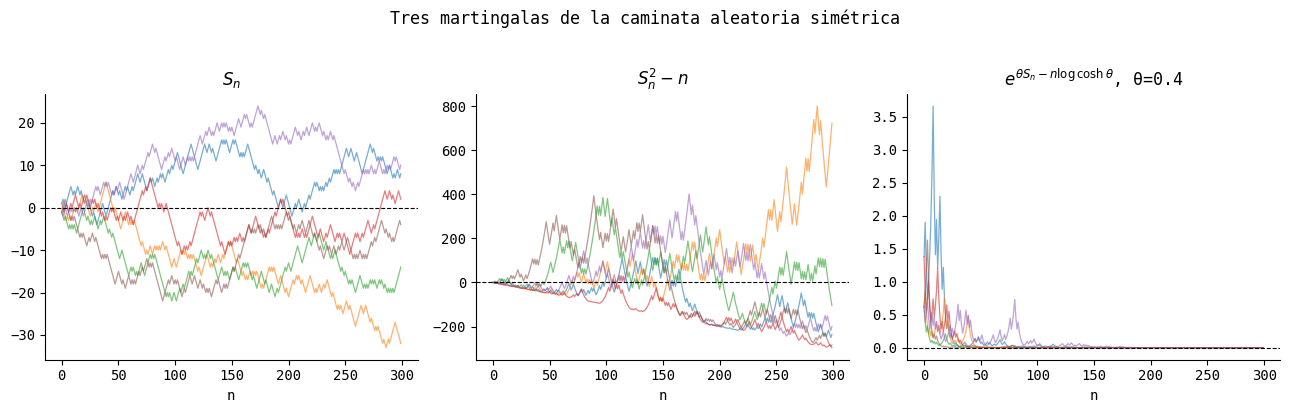

In [4]:
np.random.seed(1)
n_pasos, n_tray = 300, 6

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
theta = 0.4

for _ in range(n_tray):
    xi = 2 * np.random.randint(0, 2, n_pasos) - 1
    S = np.cumsum(xi)
    t = np.arange(1, n_pasos + 1)
    axes[0].plot(S, alpha=0.6, lw=0.9)
    axes[1].plot(S**2 - t, alpha=0.6, lw=0.9)
    axes[2].plot(np.exp(theta * S - t * np.log(np.cosh(theta))), alpha=0.6, lw=0.9)

for ax, title in zip(axes, ["$S_n$", "$S_n^2 - n$", f"$e^{{\\theta S_n - n\\log\\cosh\\theta}}$, θ={theta}"]):
    ax.axhline(0 if "exp" not in title else 1, color="k", lw=0.8, ls="--")
    ax.set_title(title)
    ax.set_xlabel("n")

plt.suptitle("Tres martingalas de la caminata aleatoria simétrica", y=1.02)
plt.tight_layout()
plt.show()


## 4. MCMC — Metrópolis-Hastings

Objetivo: $\pi(x) \propto e^{-x^2/2}$ (normal estándar).  
Propuesta simétrica $q(x,y) = \mathcal{N}(y \mid x, \sigma^2)$, por lo que la razón de Hastings es $\pi(y)/\pi(x)$.  
La constante de normalización **se cancela**.


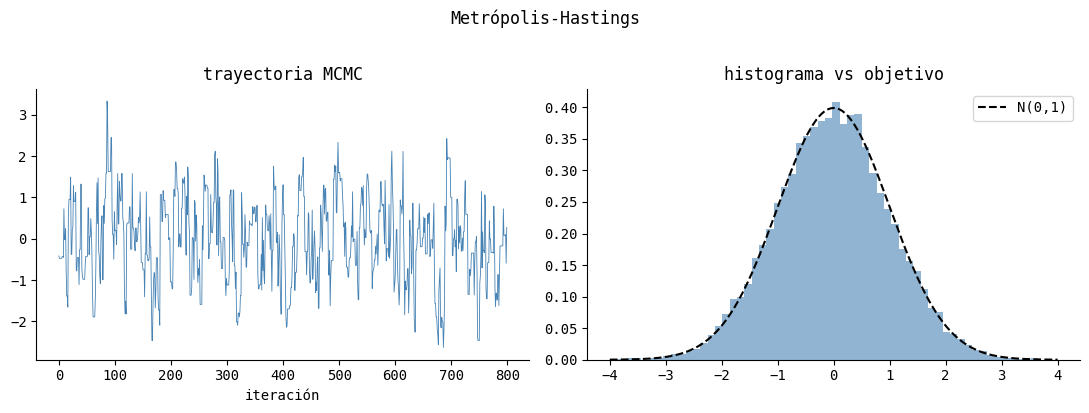

tasa de aceptación = 0.706
media muestral     = -0.0142  (esperado: 0)
desv. estándar     = 1.0104   (esperado: 1)


In [5]:
def metropolis_hastings(log_pi, sigma, n_iter=30_000, x0=0.0):
    cadena = np.empty(n_iter)
    x = x0
    aceptados = 0
    for i in range(n_iter):
        y = x + np.random.normal(0, sigma)
        if np.log(np.random.uniform()) < log_pi(y) - log_pi(x):
            x = y
            aceptados += 1
        cadena[i] = x
    return cadena, aceptados / n_iter

np.random.seed(2)
log_pi = lambda x: -0.5 * x**2
cadena, tasa = metropolis_hastings(log_pi, sigma=1.0)
muestra = cadena[3000:]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(cadena[:800], lw=0.6, color="steelblue")
axes[0].set_title("trayectoria MCMC")
axes[0].set_xlabel("iteración")

x_grid = np.linspace(-4, 4, 300)
axes[1].hist(muestra, bins=60, density=True, alpha=0.6, color="steelblue")
axes[1].plot(x_grid, norm.pdf(x_grid), "k--", lw=1.5, label="N(0,1)")
axes[1].set_title("histograma vs objetivo")
axes[1].legend()

plt.suptitle("Metrópolis-Hastings", y=1.02)
plt.tight_layout()
plt.show()

print(f"tasa de aceptación = {tasa:.3f}")
print(f"media muestral     = {muestra.mean():.4f}  (esperado: 0)")
print(f"desv. estándar     = {muestra.std():.4f}   (esperado: 1)")


## 5. Glivenko-Cantelli y Kolmogorov-Smirnov

**Glivenko-Cantelli:** $\sup_t |\hat{F}_N(t) - F(t)| \xrightarrow{a.s.} 0$.  
**KS:** mide la mayor discrepancia vertical entre la empírica y la teórica.  
La discrepancia decrece como $O(N^{-1/2})$.


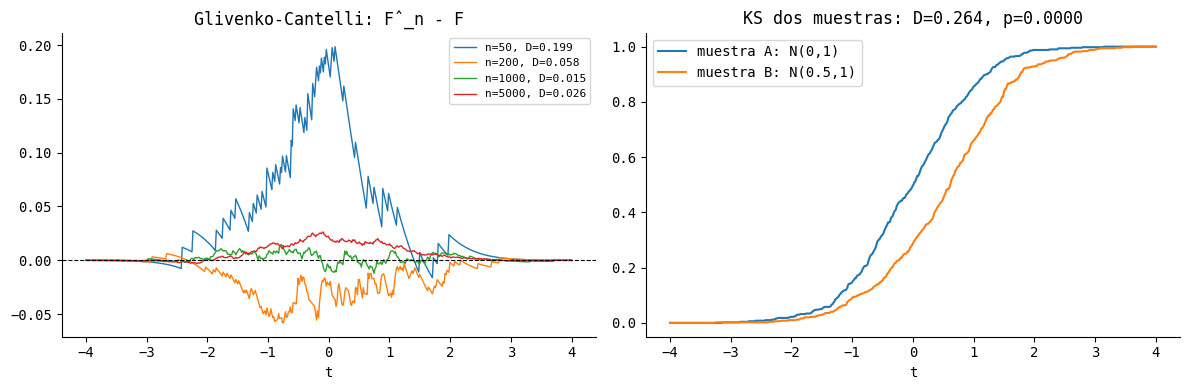

In [6]:
np.random.seed(3)
tamanios = [50, 200, 1000, 5000]
x_grid = np.linspace(-4, 4, 500)
F_verdadera = norm.cdf(x_grid)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for n in tamanios:
    muestra = np.random.normal(0, 1, n)
    Fn = np.array([(muestra <= t).mean() for t in x_grid])
    dn = np.max(np.abs(Fn - F_verdadera))
    axes[0].plot(x_grid, Fn - F_verdadera, lw=1, label=f"n={n}, D={dn:.3f}")

axes[0].axhline(0, color="k", lw=0.8, ls="--")
axes[0].set_title("Glivenko-Cantelli: F̂_n - F")
axes[0].set_xlabel("t")
axes[0].legend(fontsize=8)

# KS dos muestras
a = np.random.normal(0, 1, 500)
b = np.random.normal(0.5, 1, 500)
Fa = np.array([(a <= t).mean() for t in x_grid])
Fb = np.array([(b <= t).mean() for t in x_grid])
stat, pval = ks_2samp(a, b)

axes[1].plot(x_grid, Fa, label="muestra A: N(0,1)")
axes[1].plot(x_grid, Fb, label="muestra B: N(0.5,1)")
axes[1].set_title(f"KS dos muestras: D={stat:.3f}, p={pval:.4f}")
axes[1].set_xlabel("t")
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Ley de grandes números vía martingalas

Sea $D_k = X_k - \mu$ con $X_k$ iid. Entonces $(D_k)$ son diferencias de martingala.  
Bajo $\sum_n E[D_n^2]/n^2 < \infty$, el promedio $\frac{1}{n}\sum_{k=1}^n D_k \to 0$ c.s.


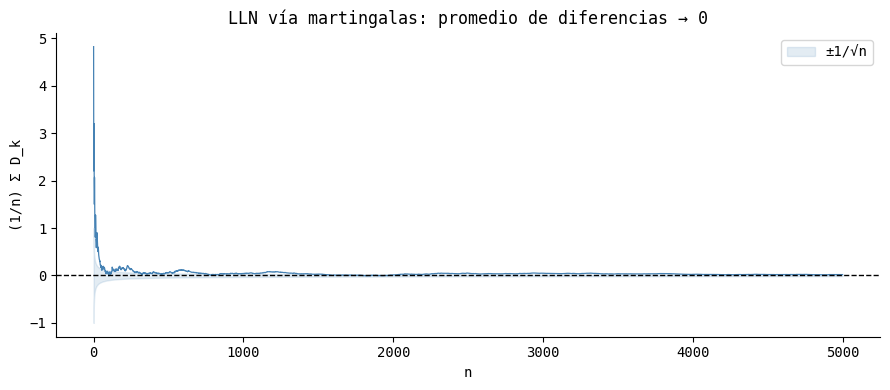

promedio final: 0.01860  (esperado: 0)


In [7]:
np.random.seed(4)
n = 5000
mu = 2.0
X = np.random.exponential(scale=mu, size=n)
D = X - mu
promedios = np.cumsum(D) / np.arange(1, n + 1)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(promedios, lw=0.9, color="steelblue")
ax.axhline(0, color="k", lw=1, ls="--")
ax.fill_between(range(n), -1/np.sqrt(np.arange(1, n+1)),
                1/np.sqrt(np.arange(1, n+1)), alpha=0.15, color="steelblue", label="±1/√n")
ax.set_xlabel("n")
ax.set_ylabel("(1/n) Σ D_k")
ax.set_title("LLN vía martingalas: promedio de diferencias → 0")
ax.legend()
plt.tight_layout()
plt.show()

print(f"promedio final: {promedios[-1]:.5f}  (esperado: 0)")


## 7. Portafolio de mínima varianza — Markowitz

Solución cerrada: $w_{GMV} = \frac{\Sigma^{-1}\mathbf{1}}{\mathbf{1}^\top \Sigma^{-1} \mathbf{1}}$

La frontera eficiente traza la relación riesgo-retorno mínimo para cada nivel de rendimiento objetivo.


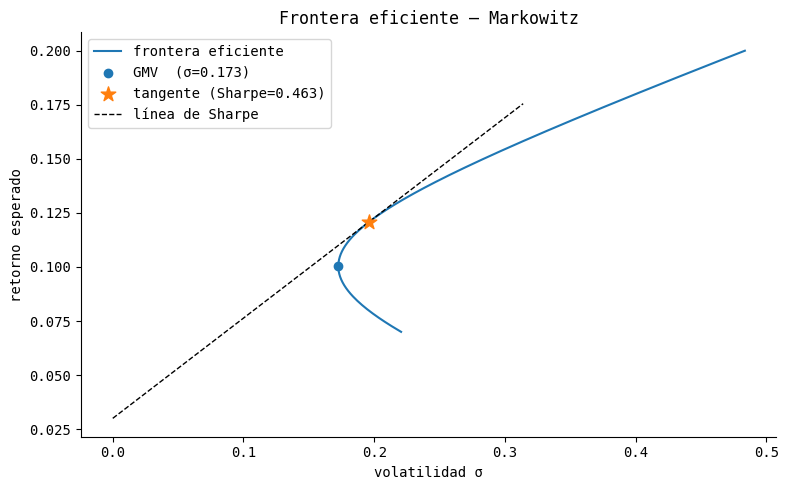

w_GMV     = [0.6532 0.2179 0.1289]
retorno   = 0.1003,  volatilidad = 0.1725
w_tangente= [0.3728 0.3103 0.3169]


In [8]:
Sigma = np.array([
    [0.040, 0.012, 0.008],
    [0.012, 0.090, 0.018],
    [0.008, 0.018, 0.160],
])
mu = np.array([0.08, 0.12, 0.17])
rf = 0.03

# GMV
ones = np.ones(3)
Si = np.linalg.inv(Sigma)
w_gmv = Si @ ones / (ones @ Si @ ones)

# Frontera eficiente
A = ones @ Si @ ones
B = ones @ Si @ mu
C = mu  @ Si @ mu
D = A*C - B**2

ms = np.linspace(0.07, 0.20, 200)
sigmas = np.sqrt((A*ms**2 - 2*B*ms + C) / D)

# Portafolio tangente
d = mu - rf * ones
w_tan = Si @ d / (ones @ Si @ d)
ret_tan = mu @ w_tan
vol_tan = np.sqrt(w_tan @ Sigma @ w_tan)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sigmas, ms, lw=1.5, label="frontera eficiente")
ax.scatter(np.sqrt(w_gmv @ Sigma @ w_gmv), mu @ w_gmv,
           zorder=5, label=f"GMV  (σ={np.sqrt(w_gmv@Sigma@w_gmv):.3f})")
ax.scatter(vol_tan, ret_tan, zorder=5, marker="*", s=120,
           label=f"tangente (Sharpe={((ret_tan-rf)/vol_tan):.3f})")
ax.plot([0, vol_tan*1.6], [rf, rf + (ret_tan-rf)/vol_tan * vol_tan*1.6],
        "k--", lw=1, label="línea de Sharpe")
ax.set_xlabel("volatilidad σ")
ax.set_ylabel("retorno esperado")
ax.set_title("Frontera eficiente — Markowitz")
ax.legend()
plt.tight_layout()
plt.show()

print(f"w_GMV     = {w_gmv.round(4)}")
print(f"retorno   = {(mu @ w_gmv):.4f},  volatilidad = {np.sqrt(w_gmv@Sigma@w_gmv):.4f}")
print(f"w_tangente= {w_tan.round(4)}")


## 8. Adam — optimización adaptativa precondicionada

Adam mantiene dos memorias exponenciales: $m_t$ (primer momento) y $v_t$ (segundo momento).  
La corrección de sesgo garantiza $E[\hat{m}_t] = g$, $E[\hat{v}_t] = s$ incluso en iteraciones tempranas.

$$\theta_{t+1} = \theta_t - \alpha \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \varepsilon}$$


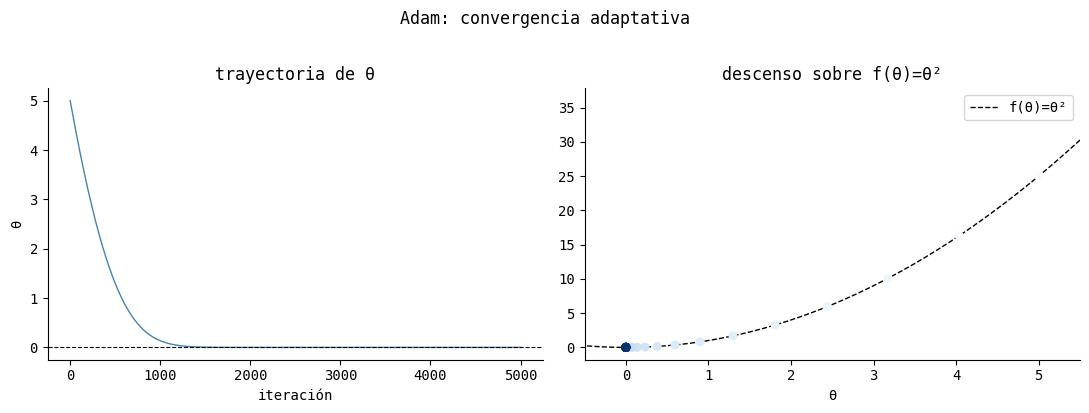

θ inicial = 5.0,  θ final = 0.00000000  (esperado: ~0)


In [9]:
def adam(grad_fn, theta0, alpha=0.01, beta1=0.9, beta2=0.999, eps=1e-8, n_iter=5000):
    theta = theta0
    m, v = 0.0, 0.0
    historia = [theta]
    for t in range(1, n_iter + 1):
        g = grad_fn(theta)
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * g**2
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)
        theta = theta - alpha * m_hat / (np.sqrt(v_hat) + eps)
        historia.append(theta)
    return np.array(historia)

# f(θ) = θ²,  mínimo en θ=0
trayectoria = adam(lambda theta: 2*theta, theta0=5.0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(trayectoria, lw=1, color="steelblue")
axes[0].axhline(0, color="k", lw=0.8, ls="--")
axes[0].set_xlabel("iteración")
axes[0].set_ylabel("θ")
axes[0].set_title("trayectoria de θ")

x_grid = np.linspace(-1, 6, 300)
axes[1].plot(x_grid, x_grid**2, "k--", lw=1, label="f(θ)=θ²")
axes[1].scatter(trayectoria[::100], trayectoria[::100]**2,
                c=range(len(trayectoria[::100])), cmap="Blues", zorder=5, s=30)
axes[1].set_xlim(-0.5, 5.5)
axes[1].set_xlabel("θ")
axes[1].set_title("descenso sobre f(θ)=θ²")
axes[1].legend()

plt.suptitle("Adam: convergencia adaptativa", y=1.02)
plt.tight_layout()
plt.show()

print(f"θ inicial = 5.0,  θ final = {trayectoria[-1]:.8f}  (esperado: ~0)")
